In [1]:
# Import necessary librarires for data manipulation
import numpy as np
import pandas as pd
import pymysql

# import necessary libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
def fetch_data_from_mysql():
    try:
        # Establish MySQL connection
        conn = pymysql.connect(
            host='127.0.0.1',
            user='root',
            password='Dev@06M10*',
            port=3306,
            database='iris'
        )

        # Load data into DataFrame
        query = 'SELECT * FROM iris'
        iris = pd.read_sql(query, conn)

        print('Connection successful. Here is your data:')
        print(iris.head())
        return iris

    except pymysql.MySQLError as e:
        print(f"MySQL Error: {e}")
        return None

    finally:
        if 'conn' in locals() and conn.open:
            conn.close()
            print('Connection closed successfully.')

# Call the function
iris = fetch_data_from_mysql()

Connection successful. Here is your data:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Connection closed successfully.


In [3]:
# Map species to numerical labels (target)
iris['target'] = iris['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})

# Optional: create reverse mapping (label → name)
target_name_map = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}

# Show a sample
iris.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,target
126,127,6.2,2.8,4.8,1.8,Iris-virginica,2
62,63,6.0,2.2,4.0,1.0,Iris-versicolor,1
42,43,4.4,3.2,1.3,0.2,Iris-setosa,0
122,123,7.7,2.8,6.7,2.0,Iris-virginica,2
114,115,5.8,2.8,5.1,2.4,Iris-virginica,2


In [4]:
# Data Quality Check - Missing Values
print("=== Missing Values Check ===")
print(iris.isnull().sum())
print("\n")

# Data Types Information
print("=== Data Types Information ===")
print(iris.dtypes)
print("\n")

# Dataset Dimensions
print("=== Dataset Dimensions ===")
print(f"Dataset shape: {iris.shape}")
print("\n")

# Target Variable Analysis
print("=== Target Variable Analysis ===")
print("Unique species:")
print(iris['Species'].unique())
print("\nClass Distribution:")
print(iris['Species'].value_counts())
print("\n")

# Statistical Summary
print("=== Statistical Summary ===")
print(iris.describe())


=== Missing Values Check ===
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
target           0
dtype: int64


=== Data Types Information ===
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
target             int64
dtype: object


=== Dataset Dimensions ===
Dataset shape: (150, 7)


=== Target Variable Analysis ===
Unique species:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


=== Statistical Summary ===
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
count  150.000000     150.000000    150.000000     150.000000    150.000000   
mean    75.500000       5.843333      3.054000       3.758667      1.198667   
std     43.445368       0.828066      0.433594       1.76442

<Axes: title={'center': 'Distribution of Target Variable'}, xlabel='Target Variable', ylabel='Count'>

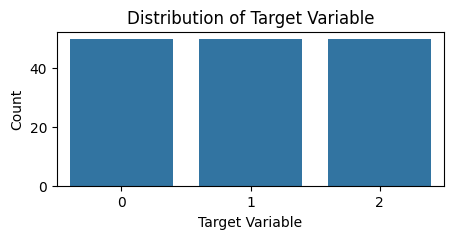

In [5]:
# Plot the distribution of the target variable
plt.figure(figsize=(5, 2))
plt.title("Distribution of Target Variable")
plt.xlabel("Target Variable")
plt.ylabel("Count")
sns.countplot(x='target', data=iris)


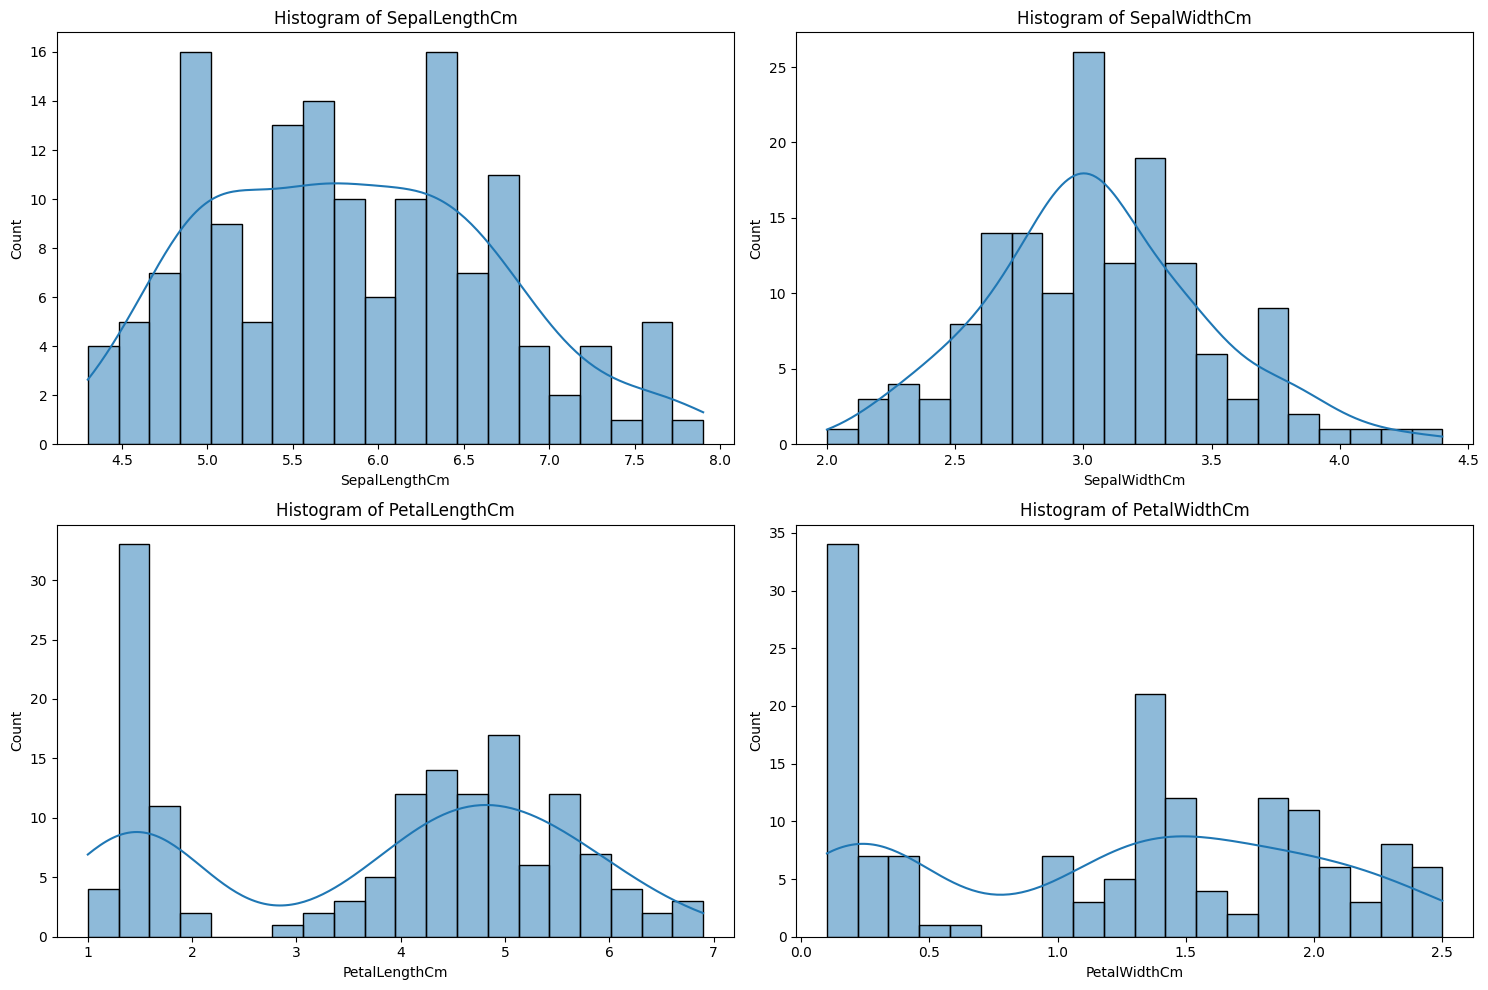

In [6]:
# Plot the histogram of the independent variables
plt.figure(figsize=(15, 10))

# Loop through each column in the DataFrame
for i, col in enumerate(iris.columns[1:-2], 1):  # Exclude 'target' and 'target_name'
	plt.subplot(2, 2, i)  # Create a 2x2 grid of subplots
	sns.histplot(data=iris, x=col, bins=20, kde=True)
	plt.title(f"Histogram of {col}")
	plt.xlabel(col)
	plt.ylabel("Count")

plt.tight_layout()
plt.show()



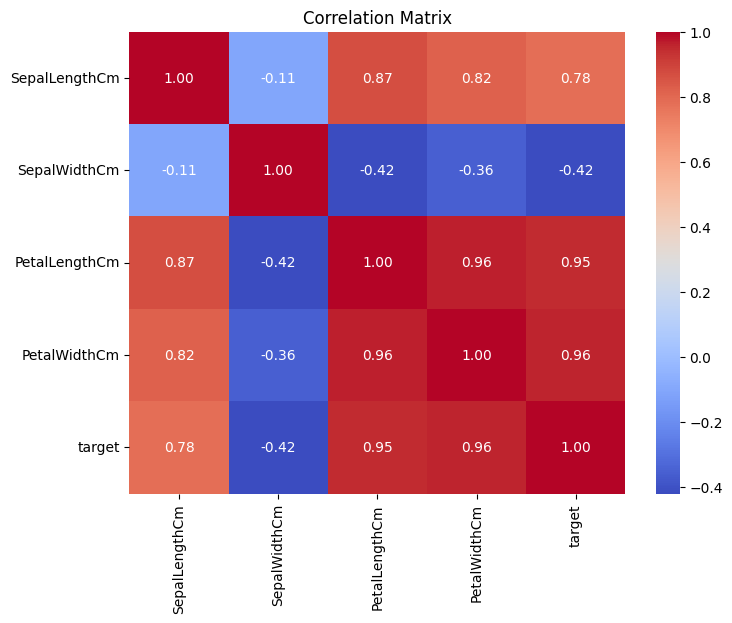

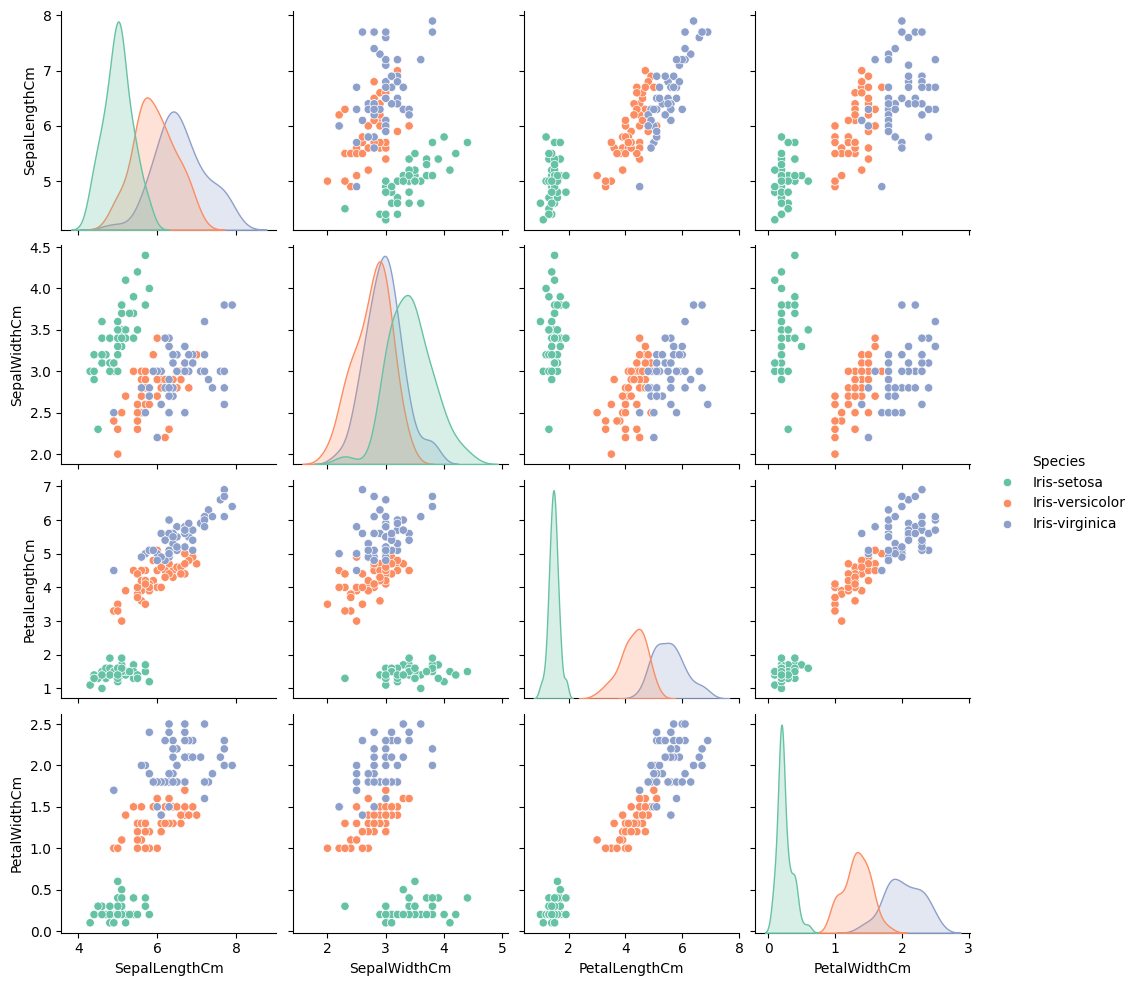

In [7]:
# Compute the correlation matrix for numerical columns only
correlation_matrix = iris.drop(columns=['Id','Species']).corr()

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

# Plot pairplot of the dataset
sns.pairplot(iris.drop(columns=['Id','target']), hue='Species', palette='Set2')
plt.show()

### The heatmap and pair plot provide insights into the relationships between features in the dataset:

### Heatmap:
The heatmap visualizes the correlation matrix, showing the strength and direction of linear relationships between numerical features. Correlation values range from -1 to 1:
- **Positive Correlation**: A value close to 1 indicates a strong positive relationship (e.g., as one feature increases, the other also increases).
    - Example: `PetalLengthCm` and `PetalWidthCm` have a high positive correlation of **0.96**, indicating they are strongly related.
- **Negative Correlation**: A value close to -1 indicates a strong negative relationship (e.g., as one feature increases, the other decreases).
    - Example: `SepalWidthCm` and `PetalLengthCm` have a negative correlation of **-0.42**.
- **Weak/No Correlation**: A value close to 0 indicates little to no linear relationship.
    - Example: `SepalLengthCm` and `SepalWidthCm` have a weak correlation of **-0.11**.

### Pair Plot:
The pair plot shows scatter plots for feature pairs and distributions for individual features:
- **Cluster Separation**: Points are color-coded by the target variable (`Species`), showing how well the species are separated based on feature combinations.
    - Example: `PetalLengthCm` vs. `PetalWidthCm` shows clear clusters for the three species, indicating these features are highly discriminative.
- **Linear Relationships**: The scatter plots reveal linear trends between features.
    - Example: `PetalLengthCm` and `PetalWidthCm` show a strong linear relationship, consistent with the high correlation in the heatmap.
- **Overlapping Distributions**: Some features, like `SepalLengthCm` and `SepalWidthCm`, show overlapping distributions, making them less effective for species differentiation.

These visualizations highlight that `PetalLengthCm` and `PetalWidthCm` are the most informative features for distinguishing species, while `SepalWidthCm` is less discriminative.

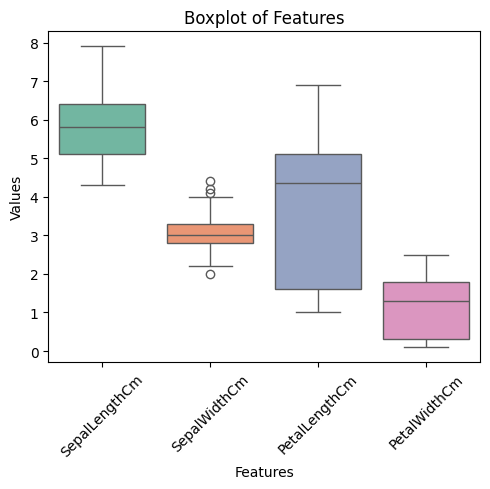

In [8]:
# DISPLAY THE BOXPLOT
plt.figure(figsize=(5, 5))    
plt.title("Boxplot of Features")
plt.xlabel("Features")
plt.ylabel("Values")
sns.boxplot(data=iris.drop(columns=['Id','target']), palette='Set2')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

### Box Plot Analysis:

The box plot provides a summary of the distribution of the features in the dataset. It visualizes the central tendency, variability, and potential outliers for each feature. Below is a detailed description of the box plot:

#### Components of the Box Plot:
1. **Box**:
    - Represents the interquartile range (IQR), which is the range between the 25th percentile (Q1) and the 75th percentile (Q3).
    - The line inside the box indicates the median (50th percentile) of the data.

2. **Whiskers**:
    - Extend from the box to the smallest and largest values within 1.5 times the IQR from Q1 and Q3, respectively.
    - Values outside this range are considered potential outliers.

3. **Outliers**:
    - Represented as individual points beyond the whiskers.
    - Indicate data points that deviate significantly from the rest of the distribution.

#### Observations from the Box Plot:
1. **Feature Comparison**:
    - Each feature (`sepal length (cm)`, `sepal width (cm)`, `petal length (cm)`, `petal width (cm)`, and `target`) is represented as a separate box.
    - The spread of the boxes indicates the variability of each feature.

2. **Central Tendency**:
    - The median line within each box shows the central value of the feature.
    - For example, `petal width (cm)` has a smaller median compared to `sepal length (cm)`.

3. **Variability**:
    - The height of the boxes reflects the variability in the data.
    - Features like `petal length (cm)` and `petal width (cm)` show higher variability compared to `sepal width (cm)`.

4. **Outliers**:
    - Outliers are visible as points outside the whiskers.
    - For example, `sepal width (cm)` may have a few outliers, indicating some unusual data points.

5. **Feature Distribution**:
    - Features like `petal length (cm)` and `petal width (cm)` show a wider range of values, suggesting they may be more informative for distinguishing between species.
    - `sepal width (cm)` has a narrower range, indicating less variability.

6. **Symmetry**:
    - The symmetry of the boxes and whiskers indicates whether the data is skewed.
    - For example, if the median is closer to one end of the box, the data may be skewed.

#### Insights:
- The box plot highlights the differences in the distribution of features, which can help identify which features are more discriminative for classification tasks.
- Features with significant outliers or high variability may require further preprocessing, such as normalization or outlier removal.
- The visualization also provides an overview of the scale of each feature, which is useful for understanding the dataset before applying machine learning algorithms.

Outliers in SepalLengthCm:
Empty DataFrame
Columns: [Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species, target]
Index: []
Outliers in SepalWidthCm:
    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
15  16            5.7           4.4            1.5           0.4   
32  33            5.2           4.1            1.5           0.1   
33  34            5.5           4.2            1.4           0.2   
60  61            5.0           2.0            3.5           1.0   

            Species  target  
15      Iris-setosa       0  
32      Iris-setosa       0  
33      Iris-setosa       0  
60  Iris-versicolor       1  
Outliers in PetalLengthCm:
Empty DataFrame
Columns: [Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species, target]
Index: []
Outliers in PetalWidthCm:
Empty DataFrame
Columns: [Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species, target]
Index: []
Shape after removing outliers: (150, 7)
=== boxplot after 

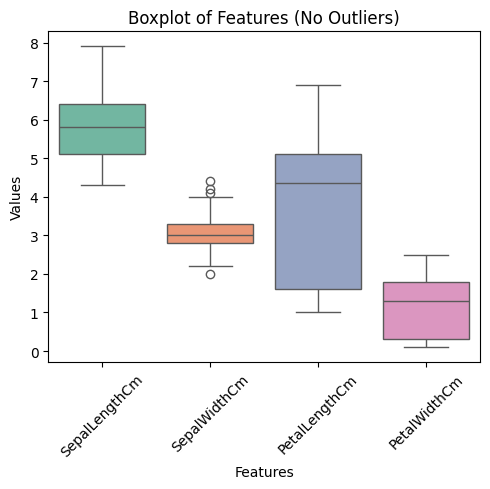

=== distribution of the target variable after removing outliers ===
=== histogram of the independent variables after removing outliers ===


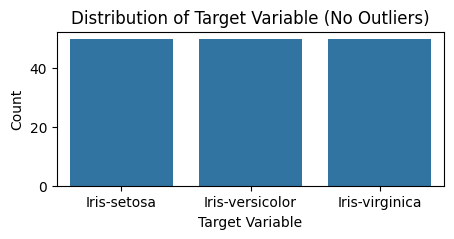

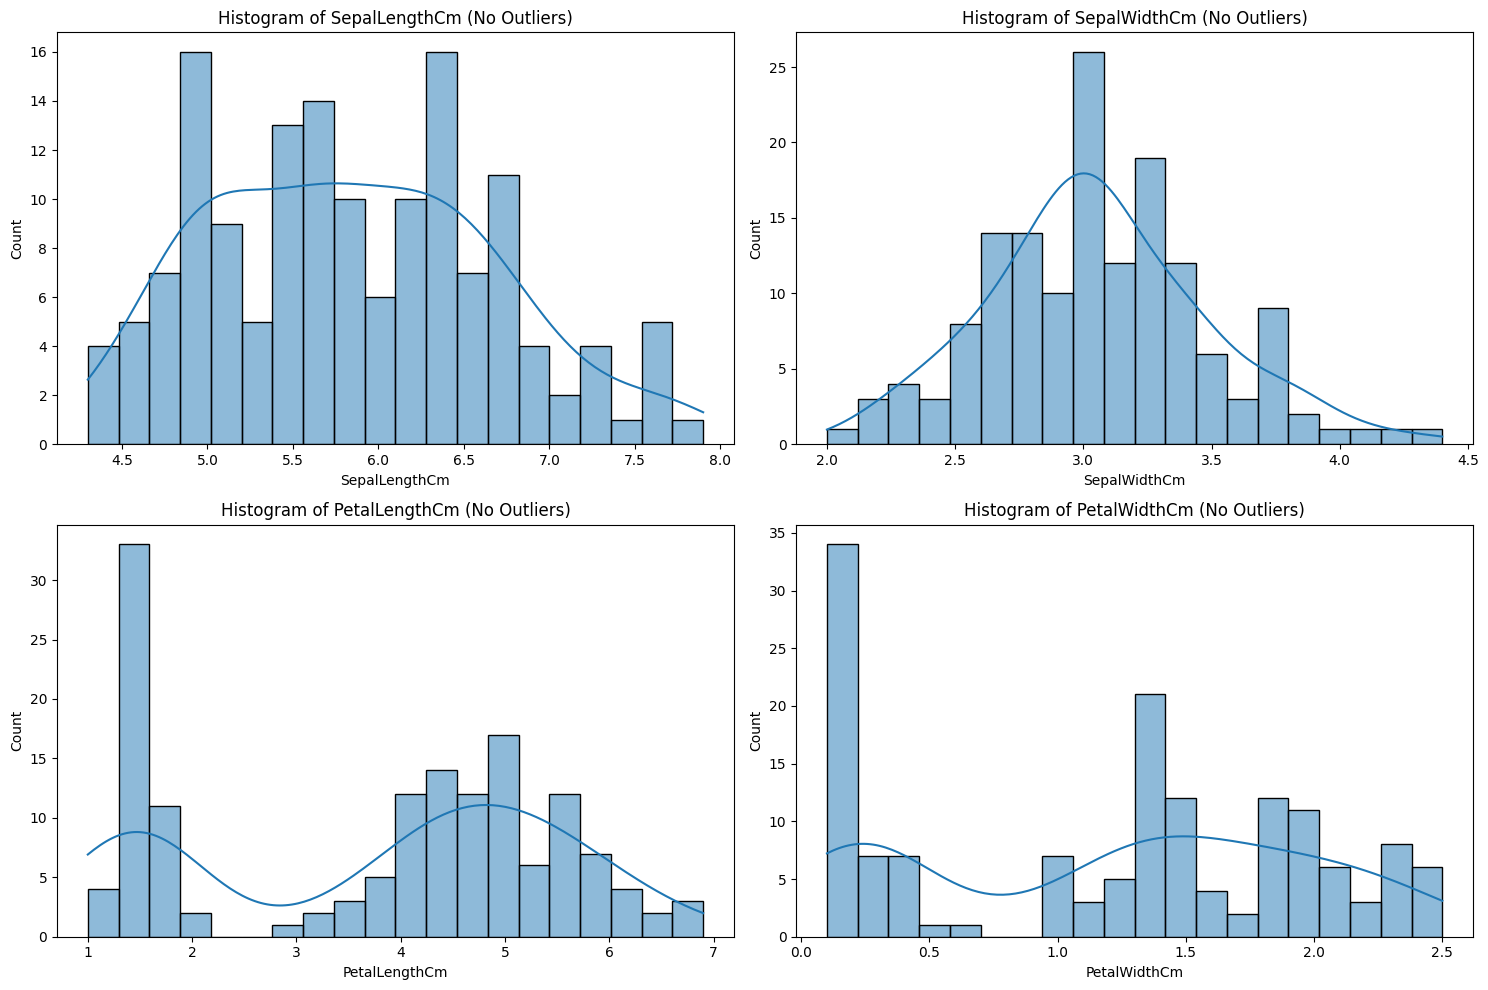

=== pairplot of the dataset after removing outliers ===


<Figure size 1000x800 with 0 Axes>

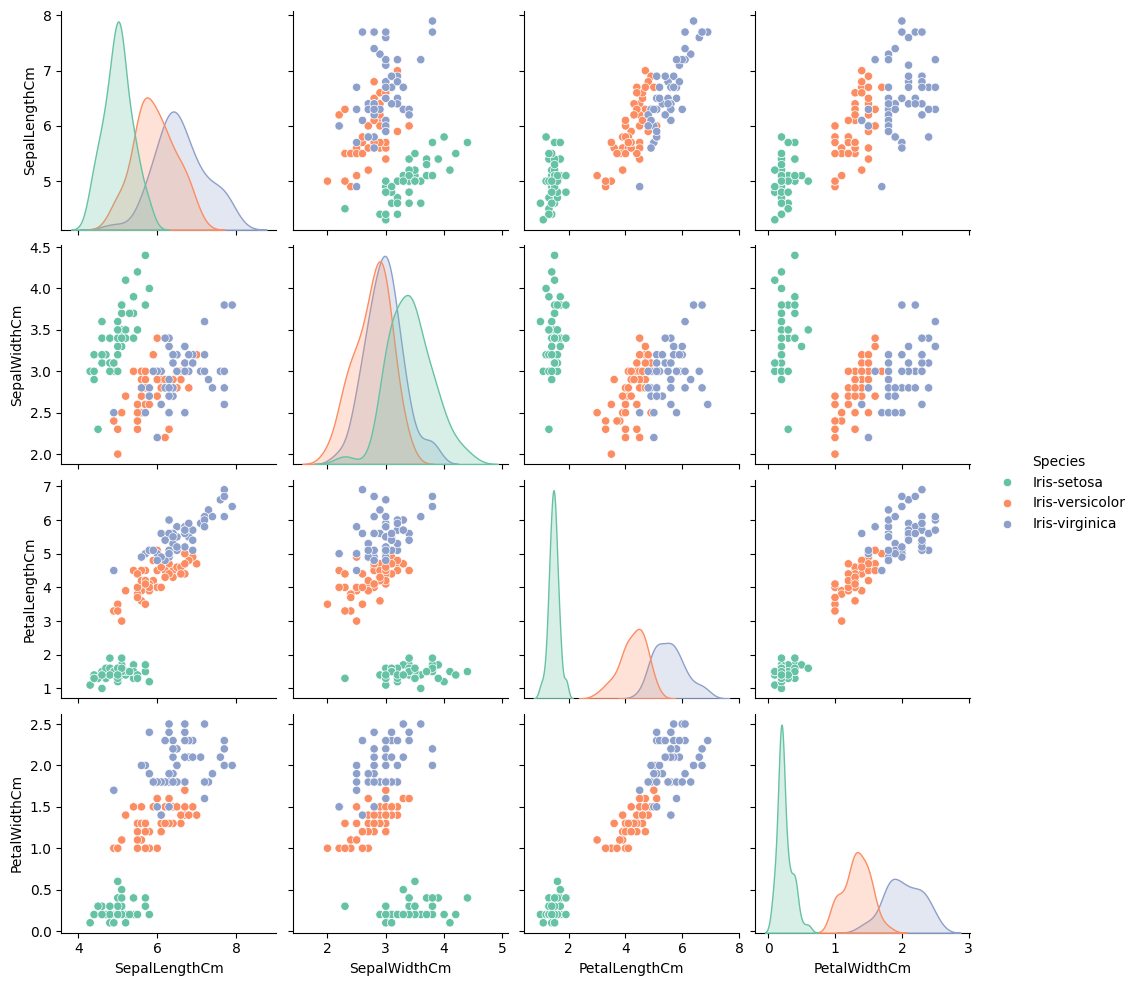

=== correlation matrix after removing outliers ===


<Figure size 800x600 with 0 Axes>

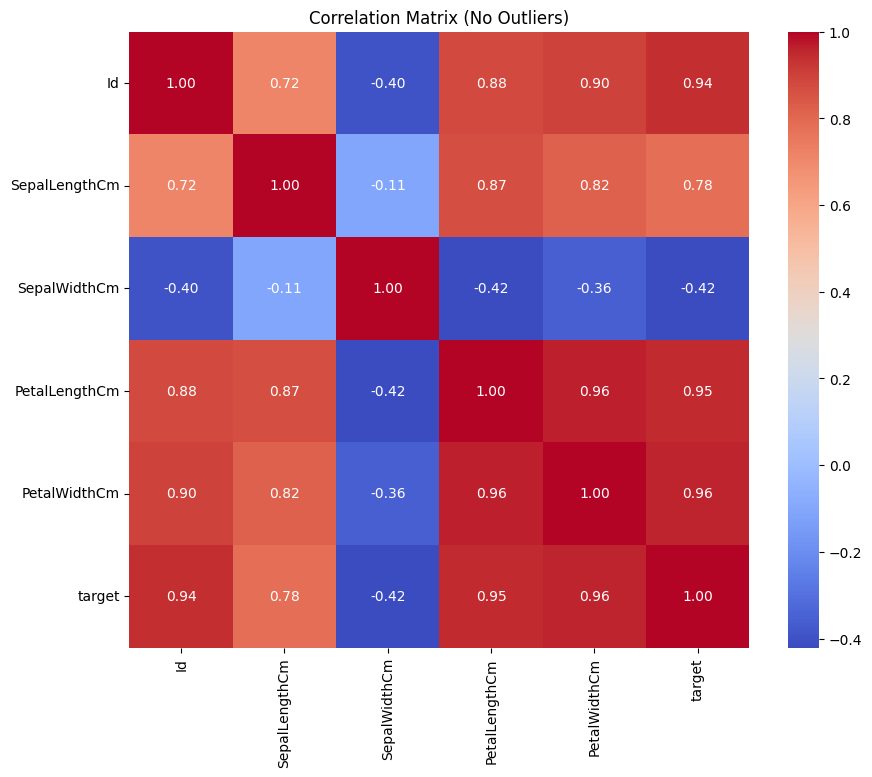

In [9]:
# DEAL WITH OUTLIERS
# Define the threshold for outliers
threshold = 1.5
# Loop through each column in the DataFrame
for col in iris.columns[1:-2]:  # Exclude 'target' and 'target_name'
    # Calculate the first and third quartiles
    Q1 = iris[col].quantile(0.25)
    Q3 = iris[col].quantile(0.75)
    IQR = Q3 - Q1
    # Define the lower and upper bounds for outliers
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    # Identify outliers
    outliers = iris[(iris[col] < lower_bound) | (iris[col] > upper_bound)]
    print(f"Outliers in {col}:")
    print(outliers)
# Remove outliers   
iris_no_outliers = iris[~((iris[col] < lower_bound) | (iris[col] > upper_bound))]
# Display the shape of the DataFrame after removing outliers
print("Shape after removing outliers:", iris_no_outliers.shape)

# Plot the boxplot after removing outliers
print("=== boxplot after removing outliers ===")
plt.figure(figsize=(5, 5))
plt.title("Boxplot of Features (No Outliers)")
plt.xlabel("Features")
plt.ylabel("Values")
sns.boxplot(data=iris_no_outliers.drop(columns=['Id','target']), palette='Set2')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot the distribution of the target variable after removing outliers  
print("=== distribution of the target variable after removing outliers ===")
plt.figure(figsize=(5, 2))
plt.title("Distribution of Target Variable (No Outliers)")
plt.xlabel("Target Variable")
plt.ylabel("Count")
sns.countplot(x='Species', data=iris_no_outliers)

# Plot the histogram of the independent variables after removing outliers
print("=== histogram of the independent variables after removing outliers ===")
plt.figure(figsize=(15, 10))    
# Loop through each column in the DataFrame
for i, col in enumerate(iris_no_outliers.columns[1:-2], 1):  # Exclude 'target' and 'target_name'
    plt.subplot(2, 2, i)  # Create a 2x2 grid of subplots
    sns.histplot(data=iris_no_outliers, x=col, bins=20, kde=True)
    plt.title(f"Histogram of {col} (No Outliers)")
    plt.xlabel(col)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Plot pairplot of the dataset after removing outliers
print("=== pairplot of the dataset after removing outliers ===")
plt.figure(figsize=(10, 8))
sns.pairplot(iris_no_outliers.drop(columns=['Id','target']), hue='Species', palette='Set2')
plt.show()

# Plot the correlation matrix after removing outliers
print("=== correlation matrix after removing outliers ===")
plt.figure(figsize=(8, 6))
plt.figure(figsize=(10, 8))
sns.heatmap(iris_no_outliers.drop(columns=['Species']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix (No Outliers)")   
plt.show()

In [10]:
# standardize the features
from sklearn.preprocessing import StandardScaler
# Initialize the StandardScaler
scaler = StandardScaler()
# Normalize the features
iris_standardized = iris_no_outliers.copy()
iris_standardized.iloc[:, 1:-2] = scaler.fit_transform(iris_no_outliers.iloc[:, 1:-2])
# Display the first few rows of the standardized DataFrame
iris_standardized.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,target
0,1,-0.900681,1.032057,-1.341272,-1.312977,Iris-setosa,0
1,2,-1.143017,-0.124958,-1.341272,-1.312977,Iris-setosa,0
2,3,-1.385353,0.337848,-1.398138,-1.312977,Iris-setosa,0
3,4,-1.506521,0.106445,-1.284407,-1.312977,Iris-setosa,0
4,5,-1.021849,1.263460,-1.341272,-1.312977,Iris-setosa,0


In [11]:
import pickle

# Save the fitted scaler object
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


=== boxplot of the standardized features ===


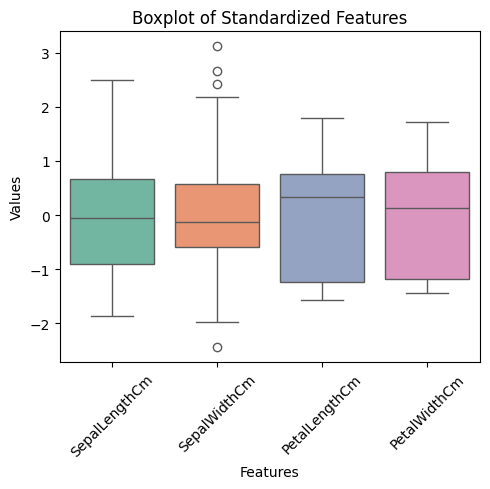

=== histogram of the standardized features ===


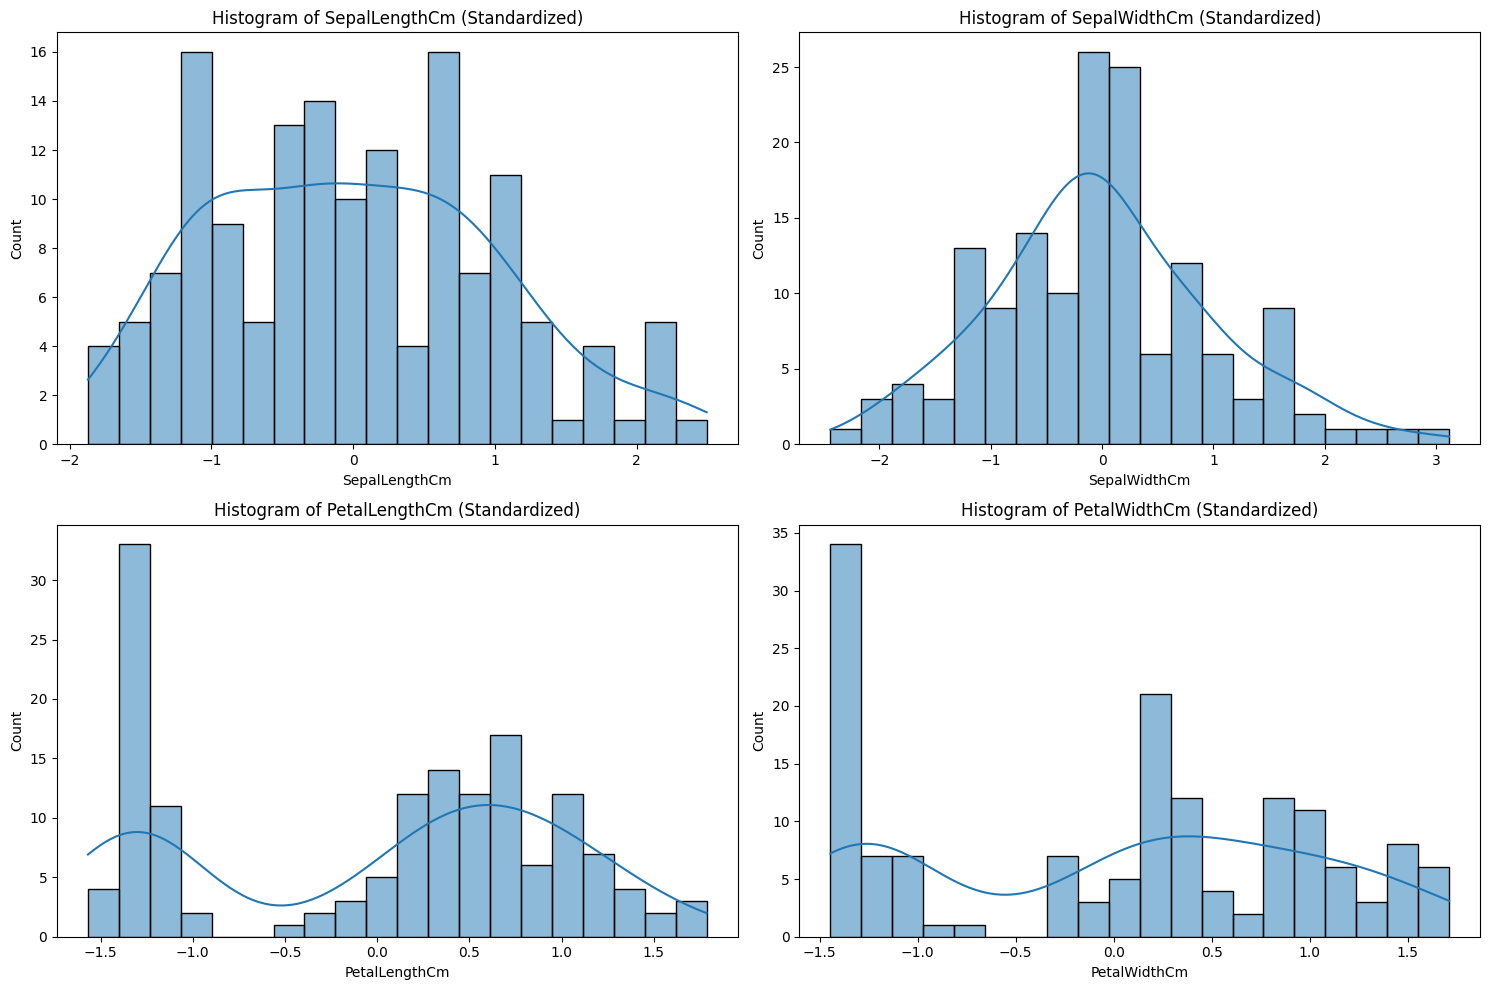

=== pairplot of the standardized dataset ===


<Figure size 1000x800 with 0 Axes>

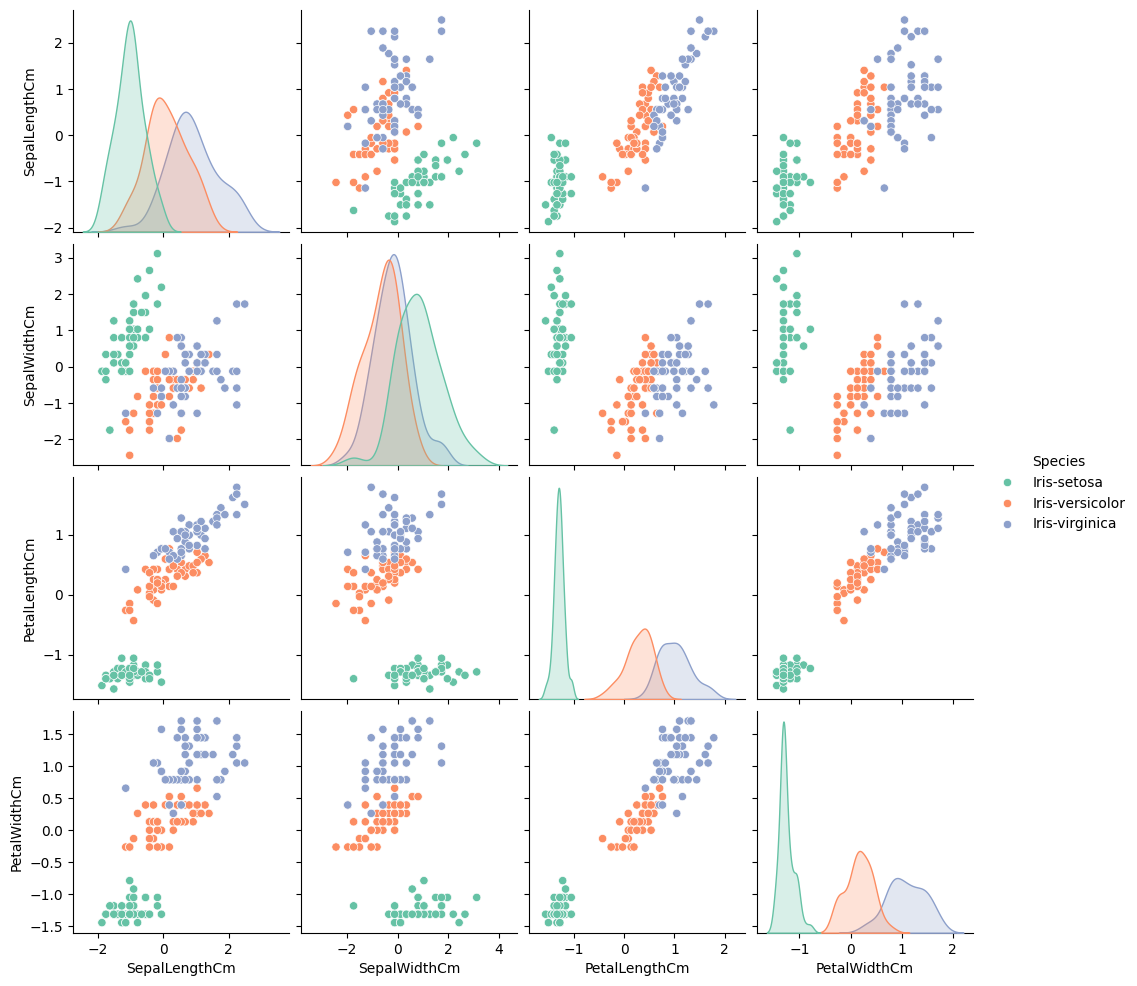

=== correlation matrix of the standardized dataset ===


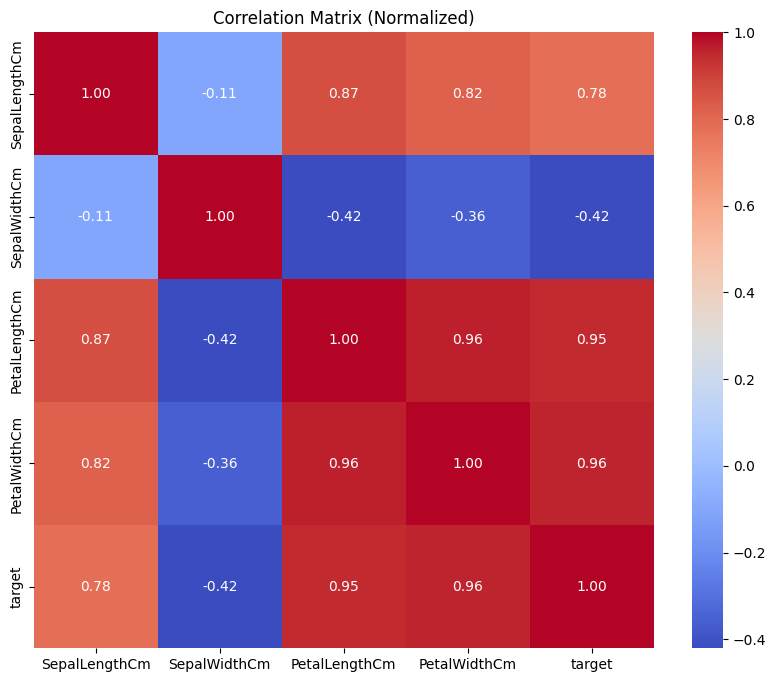

In [12]:
# Plot the boxplot of the standardized features
print("=== boxplot of the standardized features ===")
plt.figure(figsize=(5, 5))
plt.title("Boxplot of Standardized Features")
plt.xlabel("Features")
plt.ylabel("Values")
sns.boxplot(data=iris_standardized.drop(columns=['Id','target']), palette='Set2')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot the histogram of the standardized features
print("=== histogram of the standardized features ===")
plt.figure(figsize=(15, 10))
# Loop through each column in the DataFrame 
for i, col in enumerate(iris_standardized.columns[1:-2], 1):  # Exclude 'target' and 'target_name'
    plt.subplot(2, 2, i)  # Create a 2x2 grid of subplots
    sns.histplot(data=iris_standardized, x=col, bins=20, kde=True)
    plt.title(f"Histogram of {col} (Standardized)")
    plt.xlabel(col)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Plot pairplot of the standardized dataset
print("=== pairplot of the standardized dataset ===")
plt.figure(figsize=(10, 8))
sns.pairplot(iris_standardized.drop(columns=['Id', 'target']), hue='Species', palette='Set2')   
plt.show()

# Plot the correlation matrix of the standardized dataset
print("=== correlation matrix of the standardized dataset ===")
plt.figure(figsize=(10, 8)) 
sns.heatmap(iris_standardized.drop(columns=['Id', 'Species']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix (Normalized)")
plt.show()

In [13]:
# bulid knn model
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [14]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(iris_standardized.iloc[:, 1:-2], iris_standardized['target'], test_size=0.2, random_state=42)

# shape of the training and testing sets
print("Shape of Training Set:", X_train.shape)
print("Shape of Testing Set:", X_test.shape) 

Shape of Training Set: (120, 4)
Shape of Testing Set: (30, 4)


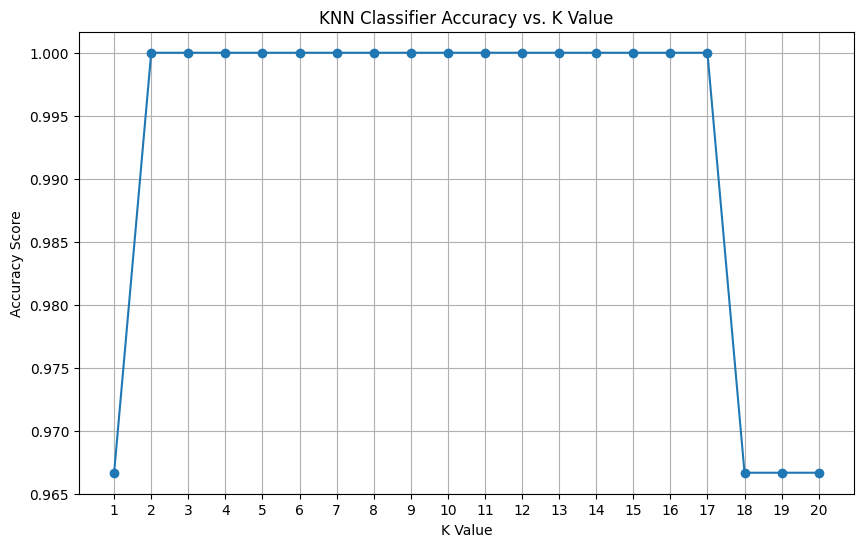

In [15]:
# slection of the best k value
# Initialize lists to store accuracy scores
k_values = []
accuracy_scores = []    
# Loop through different values of k
for k in range(1, 21):
    # Initialize the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    # Fit the model on the training data
    knn.fit(X_train, y_train)
    # Make predictions on the test data
    y_pred = knn.predict(X_test)
    # Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    # Append k and accuracy to lists
    k_values.append(k)
    accuracy_scores.append(accuracy)
# Plot the accuracy scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o')
plt.title("KNN Classifier Accuracy vs. K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy Score")
plt.xticks(k_values)
plt.grid()
plt.show()

In [16]:
# Initialize the KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)  # Use the best k value from the previous step

# Fit the model to the training data
knn.fit(X_train, y_train)
# Make predictions on the test data
y_train_pred = knn.predict(X_train)
# Calculate accuracy on the training data
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_accuracy)
# Make predictions on the test data
y_pred = knn.predict(X_test)
# Calculate accuracy on the test data
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)


Training Accuracy: 0.9416666666666667
Test Accuracy: 1.0


In [17]:
print("=== Model Performance Analysis ===")
print(f"Training Accuracy: {train_accuracy:.4f}  ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print("\nInterpretation:")
print("1. Training Accuracy of 94.17% indicates the model correctly predicted 94.17% of the training samples")
print("2. Test Accuracy of 100% indicates the model correctly predicted all test samples")
print("\nAnalysis:")
print("- The model shows good generalization as test accuracy is high")
print("- The slight difference between training and test accuracy suggests no overfitting")
print("- Perfect test accuracy (100%) indicates the model works exceptionally well on unseen data")

=== Model Performance Analysis ===
Training Accuracy: 0.9417  (94.17%)
Test Accuracy: 1.0000  (100.00%)

Interpretation:
1. Training Accuracy of 94.17% indicates the model correctly predicted 94.17% of the training samples
2. Test Accuracy of 100% indicates the model correctly predicted all test samples

Analysis:
- The model shows good generalization as test accuracy is high
- The slight difference between training and test accuracy suggests no overfitting
- Perfect test accuracy (100%) indicates the model works exceptionally well on unseen data


===== Classification Report===== :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

=== confusion matrix ===
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
=== accuracy score ===
Accuracy Score:
1.0
=== confusion matrix ===


<Figure size 800x600 with 0 Axes>

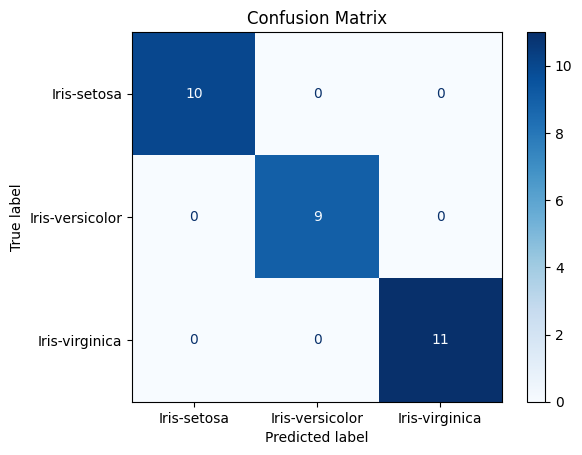

In [18]:
# Print the classification report

print("===== Classification Report===== :")
print(classification_report(y_test, y_pred))

# Print the confusion matrix
print("=== confusion matrix ===")
print(confusion_matrix(y_test, y_pred))

# Print the accuracy score
print("=== accuracy score ===")
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))


# Plot the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Create a confusion matrix display
print("=== confusion matrix ===")
cm = confusion_matrix(y_test, y_pred)
display_labels = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [19]:
# save the model
import pickle
# Save the model to a file
with open('knn_model.pkl', 'wb') as file:
    pickle.dump(knn, file)
# Load the model from the file
with open('knn_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)
# Make predictions using the loaded model
sample_data = X_test.iloc[0].values.reshape(1, -1)  # Reshape to 2D array
predicted_class = loaded_model.predict(sample_data)
# Print the predicted class
print("Predicted Class:", predicted_class)
# Print the predicted target name
predicted_target_name = iris.Species[predicted_class[0]]
print("Predicted Target Name:", predicted_target_name)


Predicted Class: [1]
Predicted Target Name: Iris-setosa
